##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** Timo & Jakub

**Student names & numbers:**
* Timo Storny - 00099699
* Jakub Holik - 00099393


---

## 0. Iteration setup

**Import libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

**Load and merge datasets**

In [3]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
# Merge them together based on the Ship_ID.
df_ship_inventory = pd.read_csv('ship_inventory.csv')
df_ship_inspection = pd.read_csv('ship_inspections_iter2.csv')

df_merged = df_ship_inventory.merge(df_ship_inspection, left_on="Ship_ID", right_on="Ship_ID", how="left")
df_merged.head()

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

**Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

**Success criteria**

*Determine success criteria for this iteration*

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In [4]:
# CODE CELL: Show basic statistics and information
df_merged.info()
df_merged.describe()
df_merged.duplicated(subset=["Ship_ID"]).sum()

<class 'pandas.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  str    
 4   Sector             368814 non-null  str    
 5   Hull_Integrity     368814 non-null  str    
 6   Reactor_Power      339345 non-null  float64
 7   Propulsion_Type    312108 non-null  str    
 8   Ship_Class         368814 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 25.3 MB


np.int64(500)

In [5]:
df_merged = df_merged.drop_duplicates(subset=["Ship_ID"], keep="first")
df_merged.duplicated(subset=["Ship_ID"]).sum()

np.int64(0)

In [6]:
df_merged["Ship_Manufacturer"].unique()

<StringArray>
[            'Galactic Motors',          'Republic Aerospace',
           'Nebula Industries',       'Corellian Engineering',
         'General Mining Corp',               'Hondo Systems',
 'Bayerische Motoren Wormhole',     'Independent Shipwrights',
            'Kuat Drive Yards',                 'Droid Works',
              'Mercurian Benz',            'Galactic Motors ',
               'Jumpship Corp',      'Independent Shipwright',
                 'Independent',                  'Kuat Drive',
             'Galactic_Motors',            'Ind. Shipwrights',
              'Corellian Eng.',           'Kuat  Drive Yards',
              'Galactic Motrs',                  'Nebula Ind',
  'Corellian Engineering Corp',                      'Nebula',
       'Nebula Industries (c)',        'Corelian Engineering',
             'GALACTIC MOTORS',                     'Kuat DY']
Length: 28, dtype: str

In [7]:
normalize = {
    "Galactic Motors": "Galactic Motors",
    "Galactic Motors ": "Galactic Motors",
    "GALACTIC MOTORS": "Galactic Motors",
    "Galactic_Motors": "Galactic Motors",
    "Galactic Motrs": "Galactic Motors",

    "Republic Aerospace": "Republic Aerospace",

    "Nebula Industries": "Nebula Industries",
    "Nebula Industries (c)": "Nebula Industries",
    "Nebula Ind": "Nebula Industries",
    "Nebula": "Nebula Industries",

    "Corellian Engineering": "Corellian Engineering",
    "Corellian Engineering Corp": "Corellian Engineering",
    "Corellian Eng.": "Corellian Engineering",
    "Corelian Engineering": "Corellian Engineering",

    "General Mining Corp": "General Mining Corp",
    "Hondo Systems": "Hondo Systems",
    "Bayerische Motoren Wormhole": "Bayerische Motoren Wormhole",

    "Independent Shipwrights": "Independent Shipwrights",
    "Independent Shipwright": "Independent Shipwrights",
    "Ind. Shipwrights": "Independent Shipwrights",
    "Independent": "Independent Shipwrights",

    "Kuat Drive Yards": "Kuat Drive Yards",
    "Kuat  Drive Yards": "Kuat Drive Yards",
    "Kuat Drive": "Kuat Drive Yards",
    "Kuat DY": "Kuat Drive Yards",

    "Droid Works": "Droid Works",
    "Mercurian Benz": "Mercurian Benz",
    "Jumpship Corp": "Jumpship Corp",
}

df_merged["Ship_Manufacturer"] = (
    df_merged["Ship_Manufacturer"]
      .map(lambda x: normalize.get(x, x))
)

df_merged["Ship_Manufacturer"].unique()

<StringArray>
[            'Galactic Motors',          'Republic Aerospace',
           'Nebula Industries',       'Corellian Engineering',
         'General Mining Corp',               'Hondo Systems',
 'Bayerische Motoren Wormhole',     'Independent Shipwrights',
            'Kuat Drive Yards',                 'Droid Works',
              'Mercurian Benz',               'Jumpship Corp']
Length: 12, dtype: str

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

Hull_Integrity
Critical       80.966825
Operational    62.849822
Pristine       72.730196
Name: Reactor_Power, dtype: float64

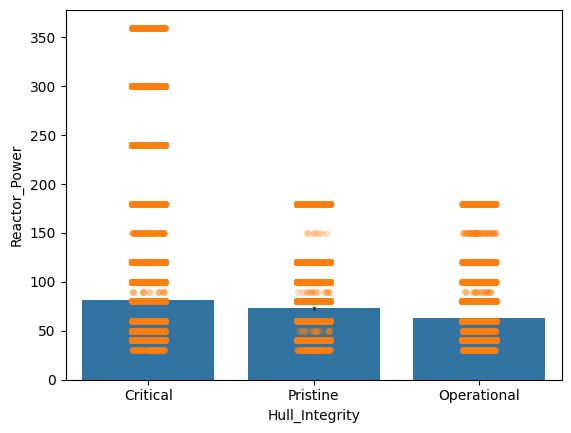

In [ ]:
# CODE CELL: Generate visualizations (e.g., bar charts, boxplots comparing features against Hull_Integrity)
sns.barplot(data=df_merged, x="Hull_Integrity", y="Reactor_Power", estimator='mean')
sns.stripplot(data=df_merged, x="Hull_Integrity", y="Reactor_Power", alpha=0.25, jitter=True)
df_merged.groupby("Hull_Integrity")["Reactor_Power"].mean()

#sns.boxplot(data=df_merged, x="Hull_Integrity", y="Reactor_Power")

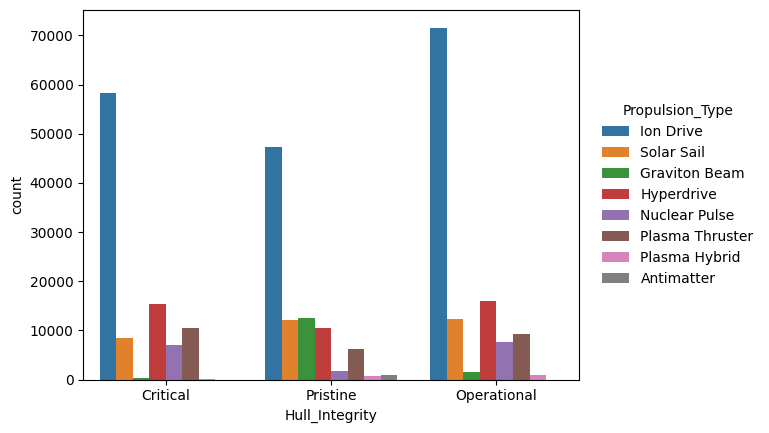

In [12]:
ax = sns.countplot(data=df_merged, x="Hull_Integrity", hue="Propulsion_Type")
sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

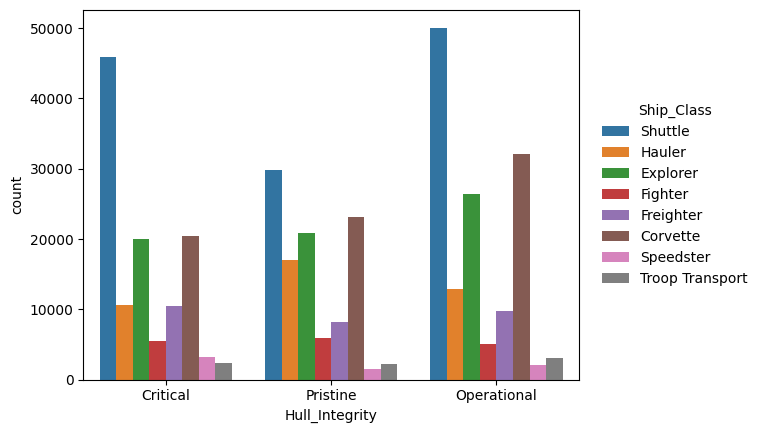

In [13]:
ax = sns.countplot(data=df_merged, x="Hull_Integrity", hue="Ship_Class")
sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

Hull_Integrity
Critical       60.223344
Operational    52.874884
Pristine       59.620257
Name: Reactor_Power, dtype: float64

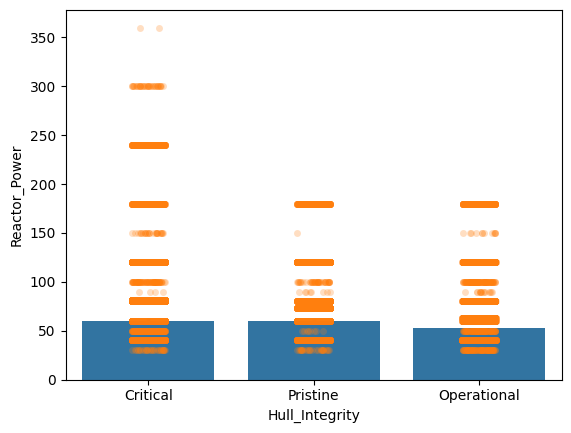

In [93]:
df_shuttle = df_merged[df_merged["Ship_Class"] == "Shuttle"]

sns.barplot(data=df_shuttle, x="Hull_Integrity", y="Reactor_Power", estimator='mean')
sns.stripplot(data=df_shuttle, x="Hull_Integrity", y="Reactor_Power", alpha=0.25, jitter=True)
df_shuttle.groupby("Hull_Integrity")["Reactor_Power"].mean()

Text(0.5, 1.0, 'Propulsion_Type distribution within each manufacturer (%)')

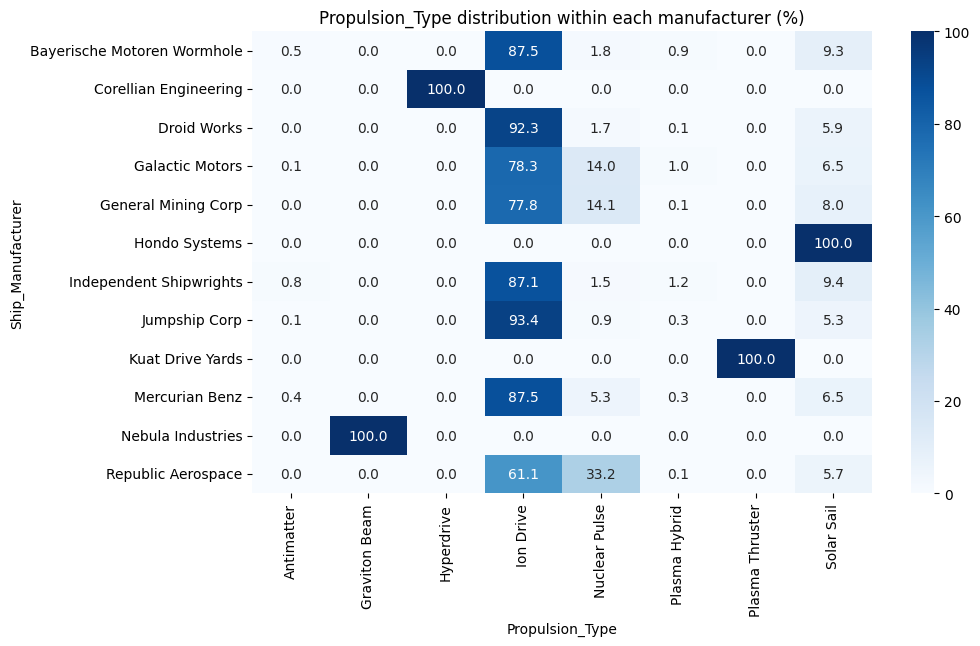

In [14]:
#ax = sns.countplot(data=df_merged, x="Ship_Manufacturer", hue="Propulsion_Type")
#sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

ct = pd.crosstab(df_merged["Ship_Manufacturer"], df_merged["Propulsion_Type"], normalize="index") * 100
plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Propulsion_Type distribution within each manufacturer (%)")

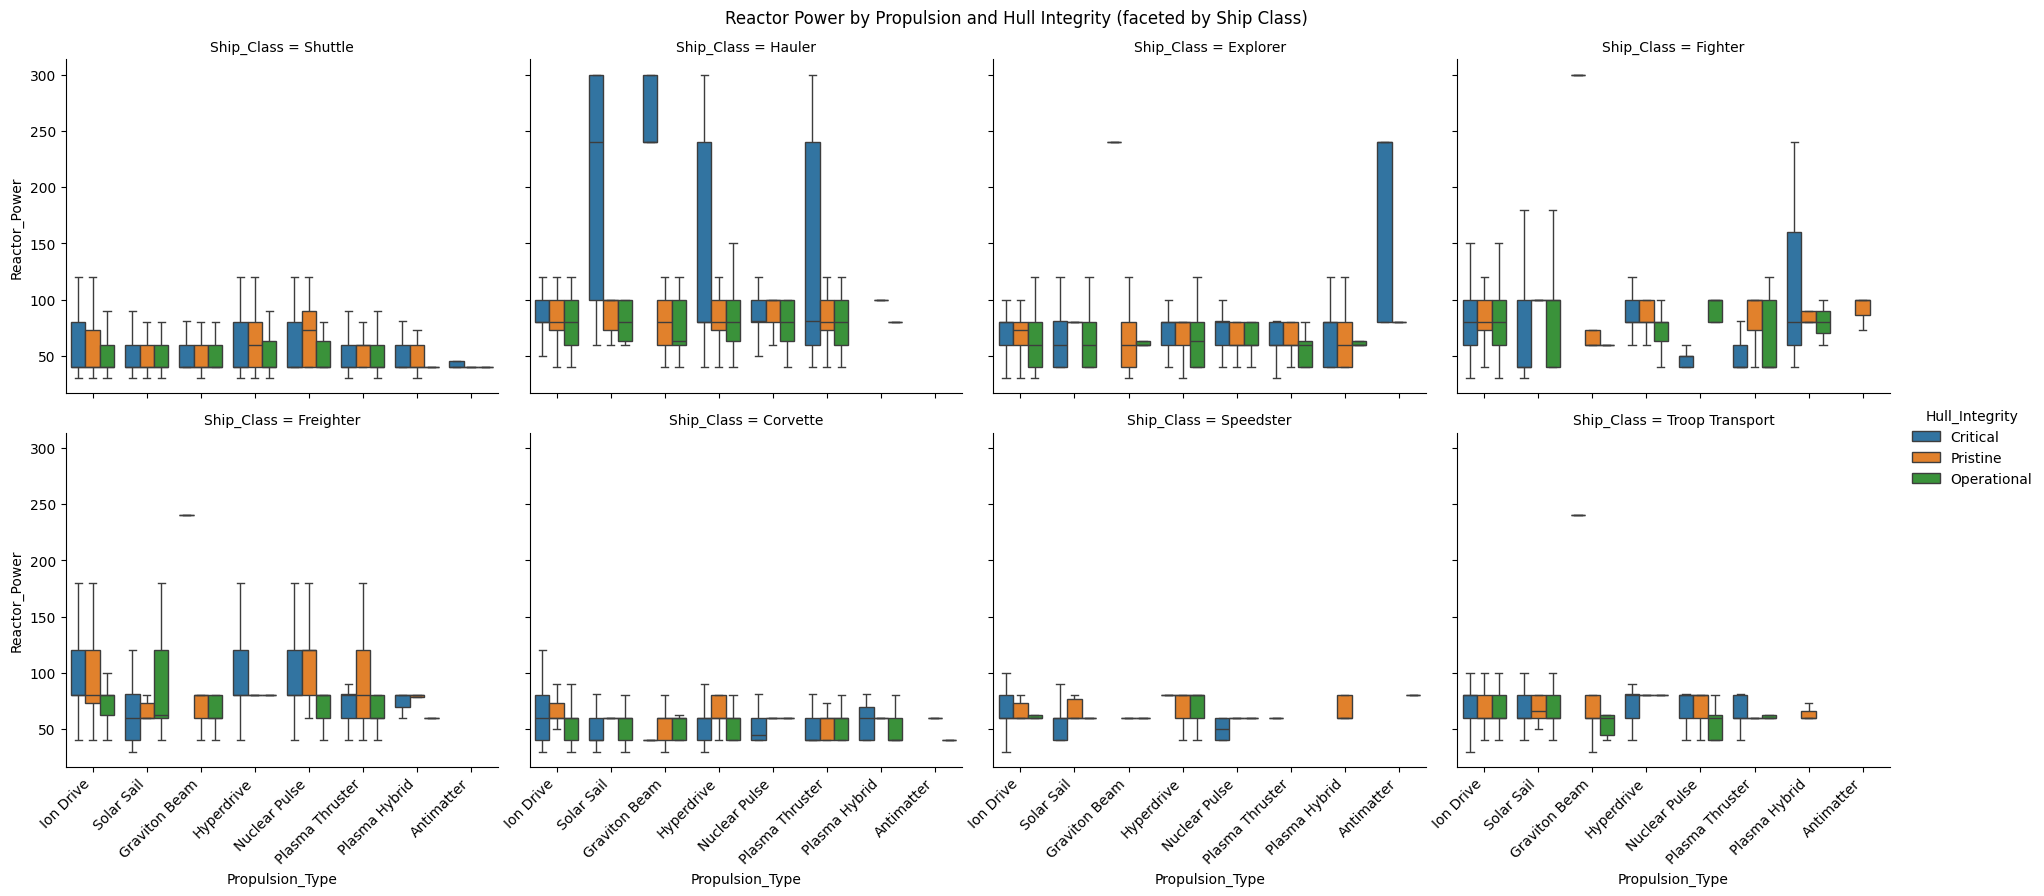

In [71]:
g = sns.catplot(
    data=df_merged,
    kind="box",
    x="Propulsion_Type",
    y="Reactor_Power",
    hue="Hull_Integrity",
    col="Ship_Class",
    col_wrap=4,
    height=4,
    aspect=1.2,
    showfliers=False
)
for i, ax in enumerate(g.axes.flat):
  if i > 3:
    ax.tick_params(axis="x", labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
g.fig.suptitle("Reactor Power by Propulsion and Hull Integrity (faceted by Ship Class)", y=1.02)
plt.show()

<Axes: xlabel='Hull_Integrity', ylabel='Galactic_Credits'>

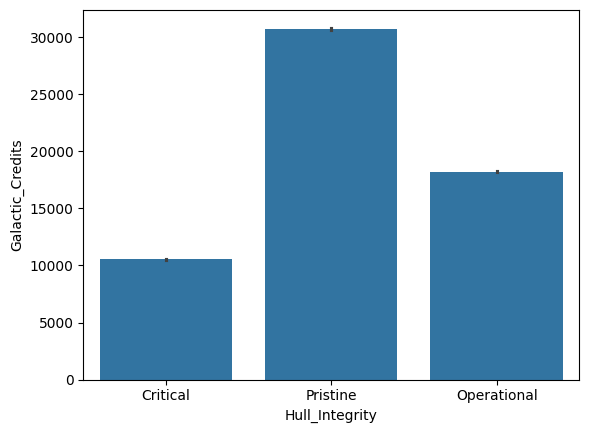

In [95]:
sns.barplot(data=df_merged, x="Hull_Integrity", y="Galactic_Credits")

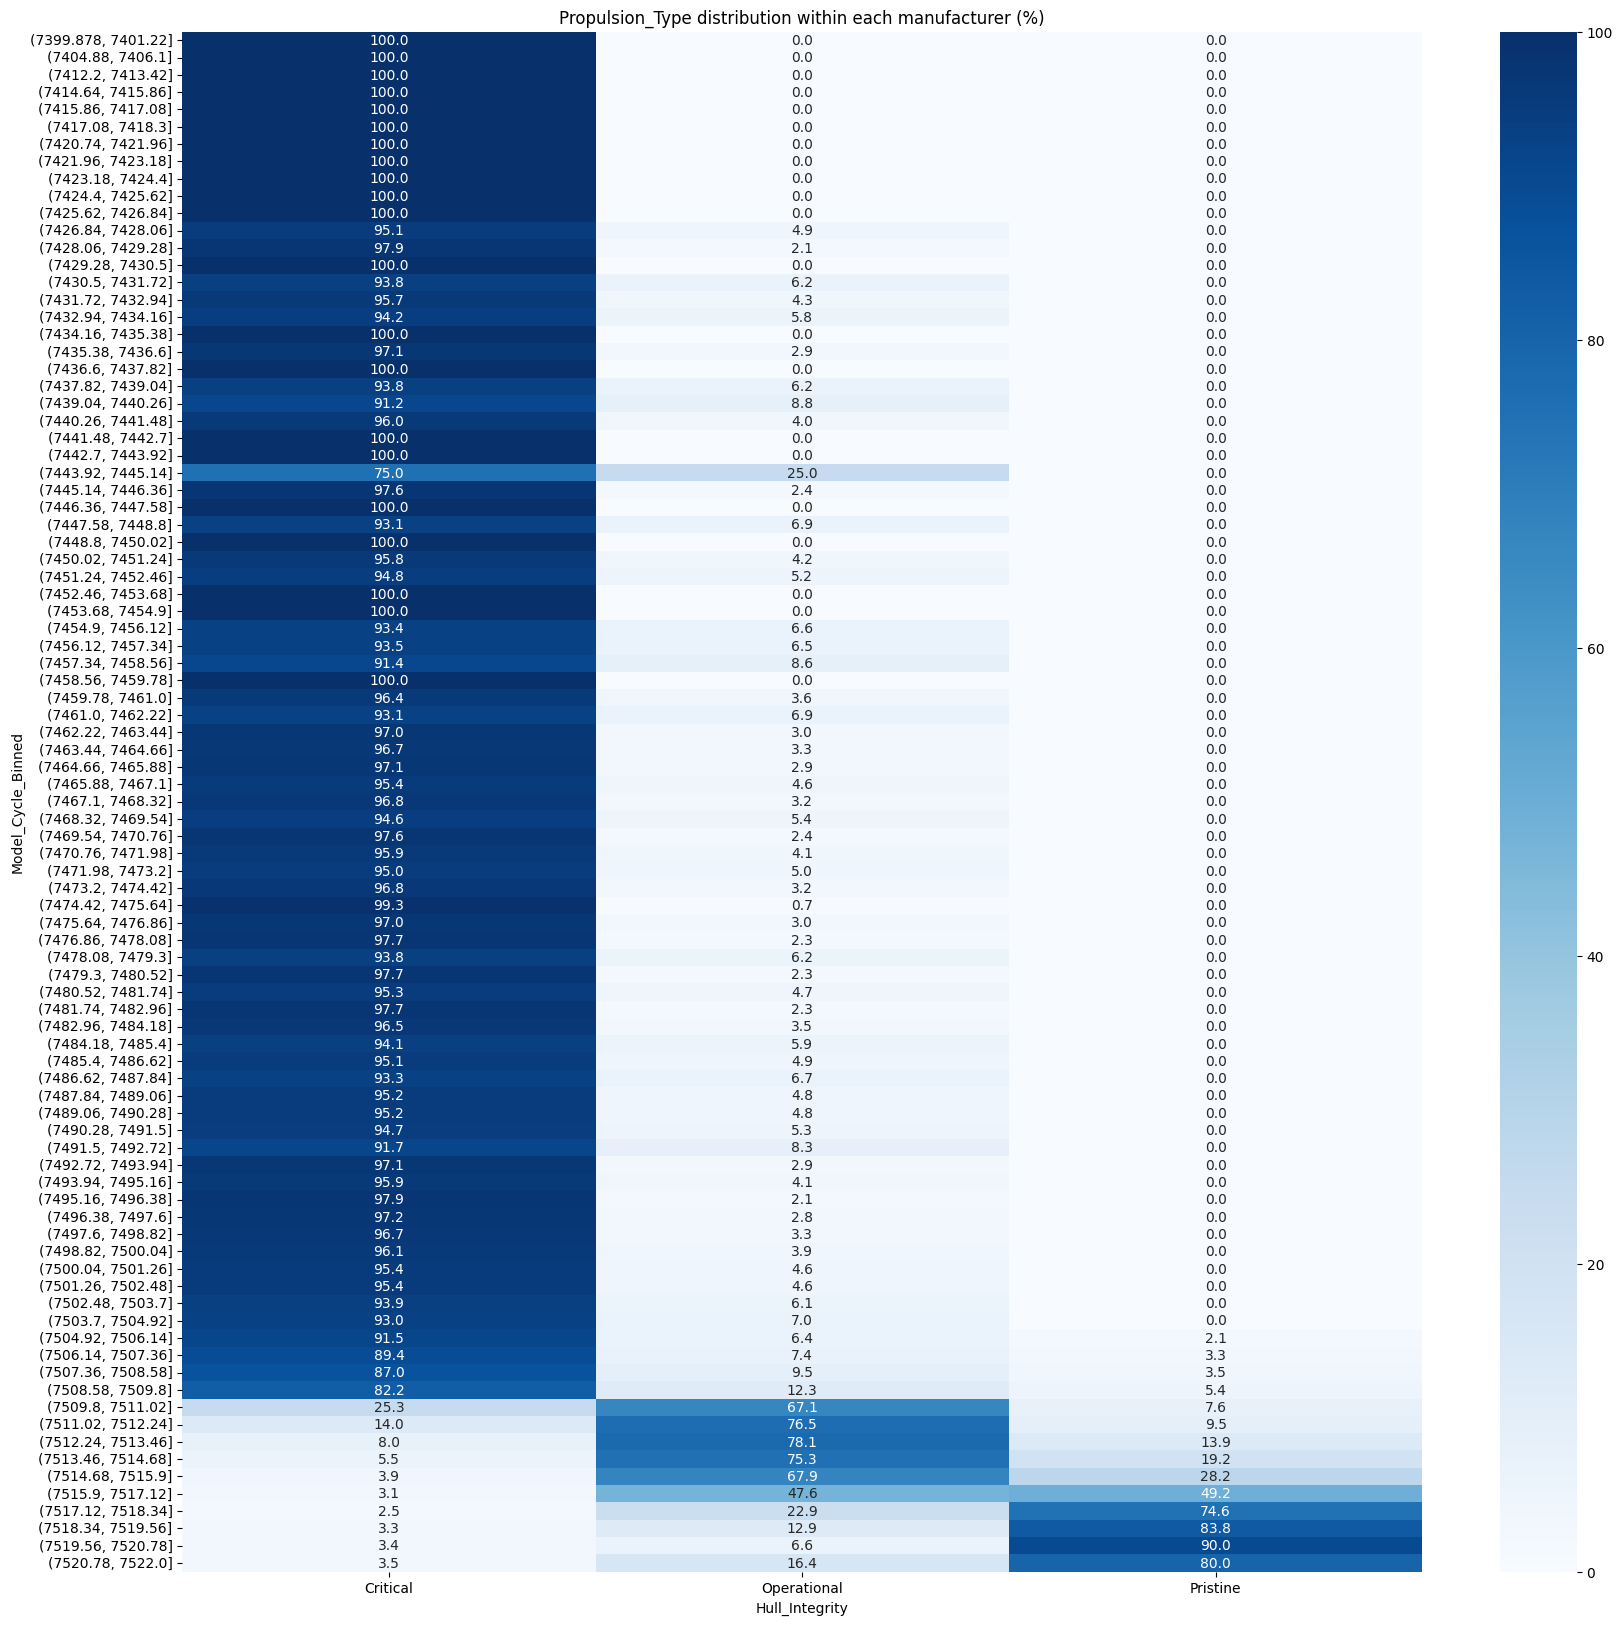

In [151]:
df_merged["Model_Cycle_Binned"] = pd.cut(df_merged["Model_Cycle"], bins=100)

# Run the crosstab on the binned column instead
ct = pd.crosstab(df_merged["Model_Cycle_Binned"], df_merged["Hull_Integrity"], normalize="index") * 100

plt.figure(figsize=(20, 20))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Propulsion_Type distribution within each manufacturer (%)")
plt.show()

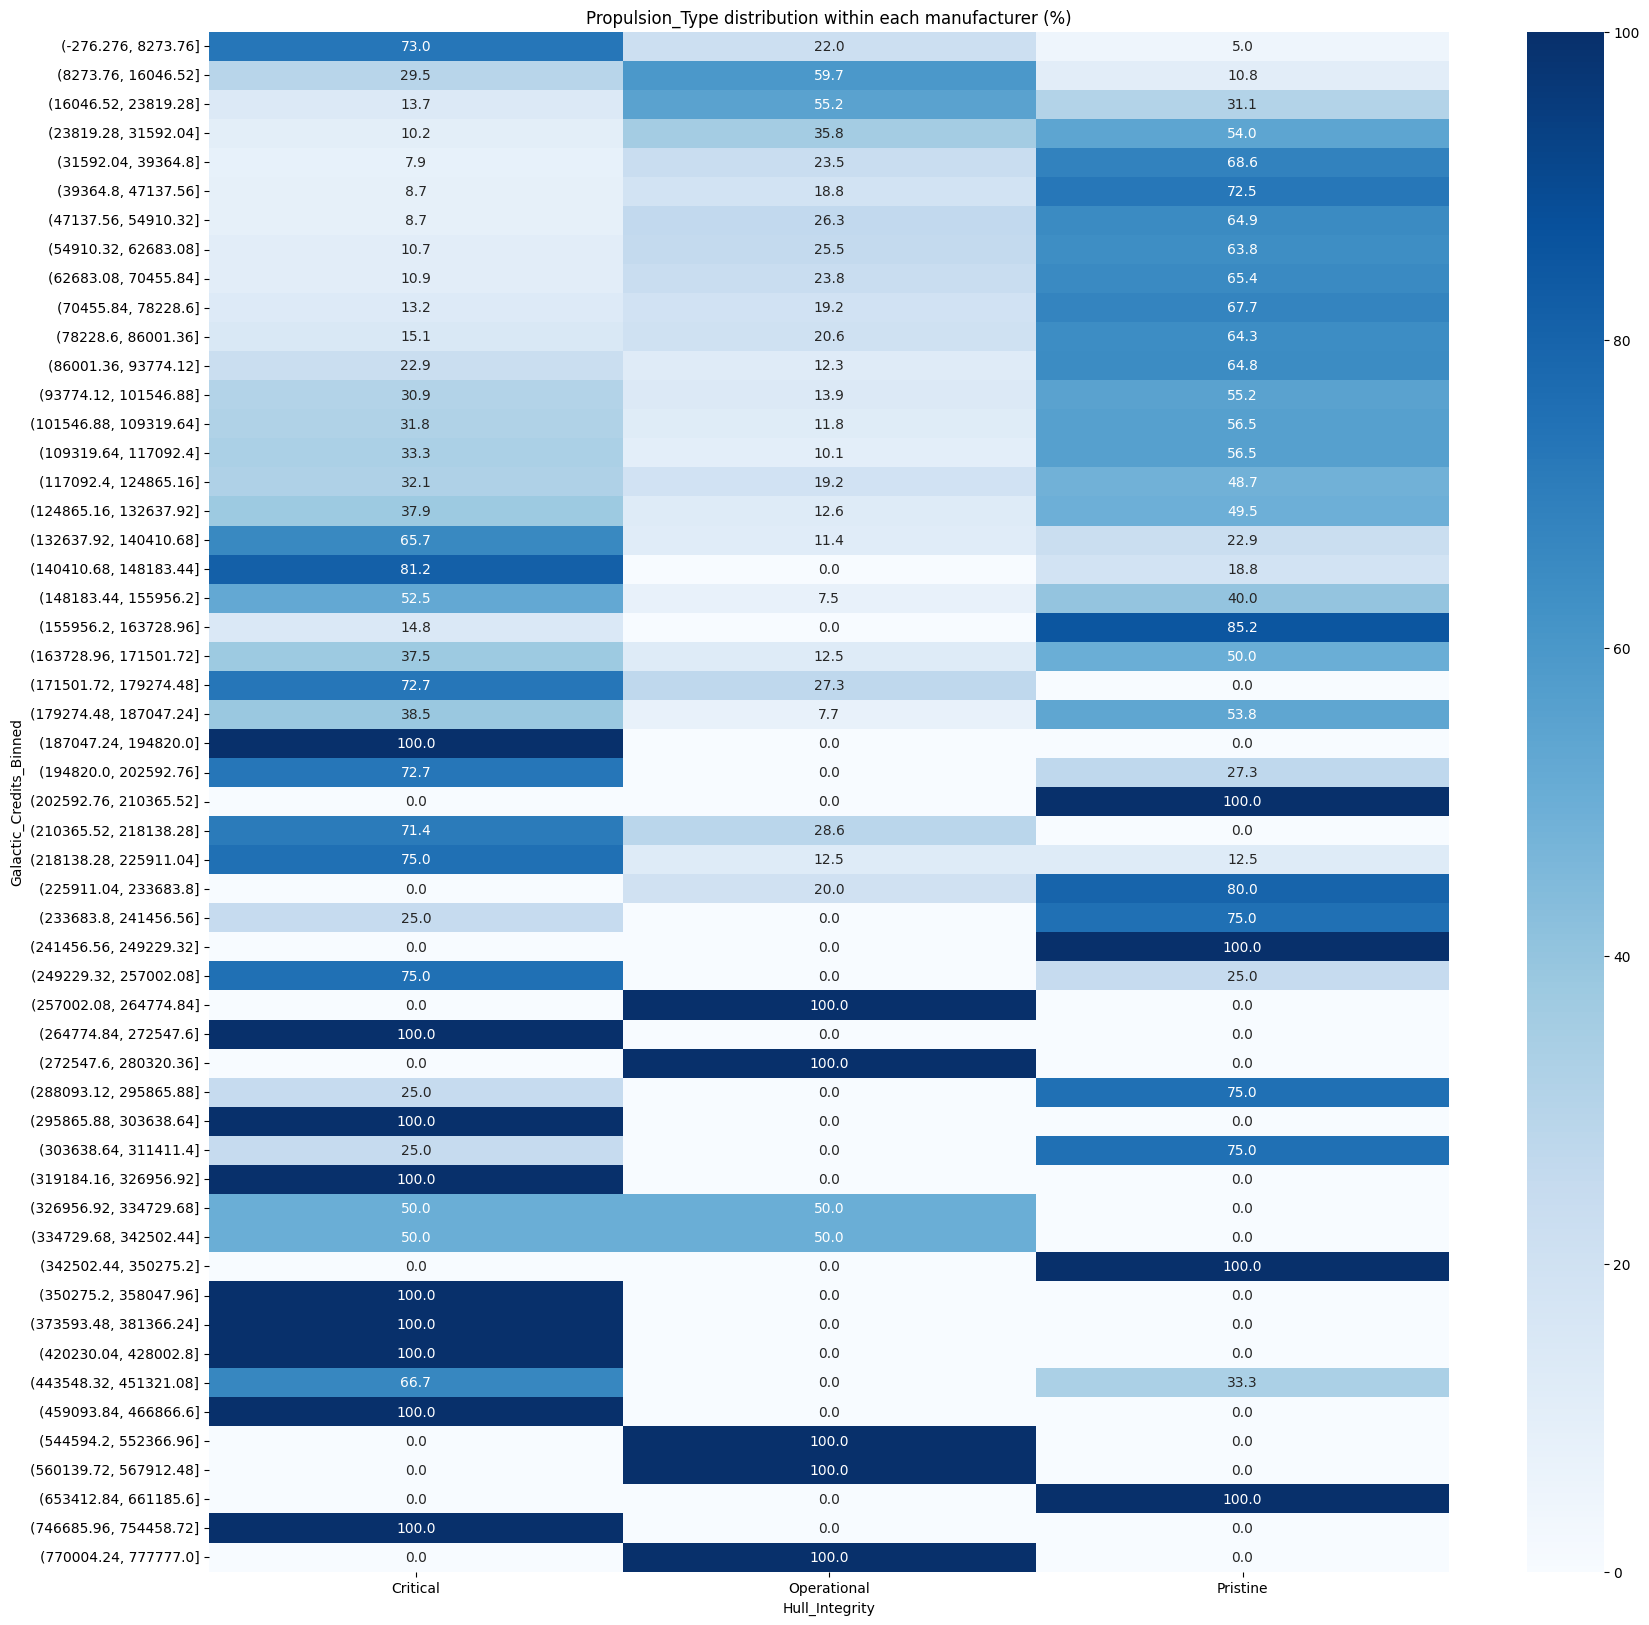

In [152]:
df_merged["Galactic_Credits_Binned"] = pd.cut(df_merged["Galactic_Credits"], bins=100)

# Run the crosstab on the binned column instead
ct = pd.crosstab(df_merged["Galactic_Credits_Binned"], df_merged["Hull_Integrity"], normalize="index") * 100

plt.figure(figsize=(20, 20))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Propulsion_Type distribution within each manufacturer (%)")
plt.show()

<Axes: xlabel='Hull_Integrity'>

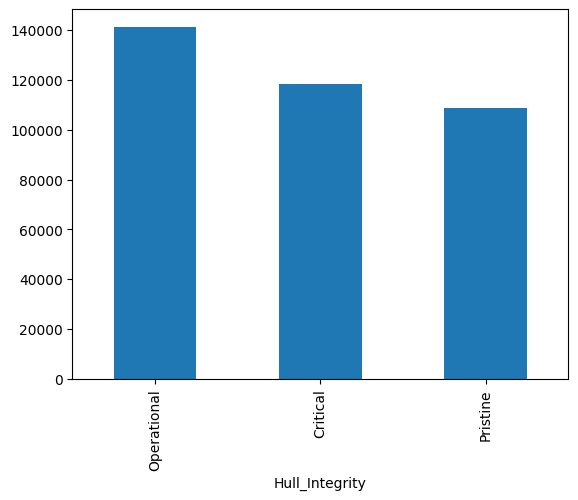

In [16]:
df_merged["Hull_Integrity"].value_counts().plot.bar()

**Data insights and data quality**
* **Insights:** What clear rules/patterns did you find that we can use for classification later?
* **Quality issues:** Document missing values (specifically in Propulsion and Reactor) and outliers.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [17]:
df_merged = df_merged.dropna(subset=["Model_Cycle"])
df_merged.info()

<class 'pandas.DataFrame'>
Index: 360916 entries, 0 to 368813
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            360916 non-null  int64  
 1   Galactic_Credits   360916 non-null  int64  
 2   Model_Cycle        360916 non-null  float64
 3   Ship_Manufacturer  360916 non-null  str    
 4   Sector             360916 non-null  str    
 5   Hull_Integrity     360916 non-null  str    
 6   Reactor_Power      332063 non-null  float64
 7   Propulsion_Type    305403 non-null  str    
 8   Ship_Class         360916 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 27.5 MB


In [18]:
# CODE CELL: Data cleaning, preprocessing
by_mfr_mode = (
    df_merged.dropna(subset=["Ship_Manufacturer", "Propulsion_Type"])
      .groupby("Ship_Manufacturer")["Propulsion_Type"]
      .agg(lambda s: s.value_counts().idxmax())
)
global_mode = df_merged["Propulsion_Type"].mode().iloc[0]
missing = df_merged["Propulsion_Type"].isna()
df_merged.loc[missing, "Propulsion_Type"] = (
    df_merged.loc[missing, "Ship_Manufacturer"].map(by_mfr_mode).fillna(global_mode)
)

df_merged.info()

<class 'pandas.DataFrame'>
Index: 360916 entries, 0 to 368813
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            360916 non-null  int64  
 1   Galactic_Credits   360916 non-null  int64  
 2   Model_Cycle        360916 non-null  float64
 3   Ship_Manufacturer  360916 non-null  str    
 4   Sector             360916 non-null  str    
 5   Hull_Integrity     360916 non-null  str    
 6   Reactor_Power      332063 non-null  float64
 7   Propulsion_Type    360916 non-null  str    
 8   Ship_Class         360916 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 27.5 MB


In [19]:
mean_by_integrity = (
    df_merged.dropna(subset=["Hull_Integrity", "Reactor_Power"])
      .groupby("Hull_Integrity")["Reactor_Power"]
      .mean()
)
global_mean = df_merged["Reactor_Power"].mean()
mask = df_merged["Reactor_Power"].isna()
df_merged.loc[mask, "Reactor_Power"] = (
    df_merged.loc[mask, "Hull_Integrity"].map(mean_by_integrity).fillna(global_mean)
)

df_merged.info()

<class 'pandas.DataFrame'>
Index: 360916 entries, 0 to 368813
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            360916 non-null  int64  
 1   Galactic_Credits   360916 non-null  int64  
 2   Model_Cycle        360916 non-null  float64
 3   Ship_Manufacturer  360916 non-null  str    
 4   Sector             360916 non-null  str    
 5   Hull_Integrity     360916 non-null  str    
 6   Reactor_Power      360916 non-null  float64
 7   Propulsion_Type    360916 non-null  str    
 8   Ship_Class         360916 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 27.5 MB


**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [20]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [120]:
target = df_merged["Hull_Integrity"]

# features is called X a lot in documentation
features = df_merged[["Reactor_Power", "Propulsion_Type", "Ship_Class", "Galactic_Credits", "Model_Cycle"]]

# random_state to get reproduceable results
feature_train, feature_test, target_train, target_test = train_test_split(features, target, test_size=0.25, random_state=2)

In [121]:
value = "Operational"

pred_train = [value] * len(target_train)

pred_test = [value] * len(target_test)

In [122]:
print("The length of y_train is:", len(target_train))
print("The length of y_test is:", len(target_test))

The length of y_train is: 270687
The length of y_test is: 90229


In [123]:
print("Accuracy of train set:", accuracy_score(pred_train, target_train))
print("Accuracy of test set:", accuracy_score(pred_test, target_test))

Accuracy of train set: 0.3834539523508702
Accuracy of test set: 0.3841337042414301


In [ ]:
def classification_model(row):
    rp = row["Reactor_Power"]
    pt = row["Propulsion_Type"]
    sc = row["Ship_Class"]
    gc = row["Galactic_Credits"]
    mc = row["Model_Cycle"]
    
    if mc <= 7509.8: 
        return "Critical"
    
    if mc >= 7517.12:
        return "Pristine"
        
    if gc > 132000:
        return "Critical"
        
    if gc >= 23819:
        return "Pristine"
        
    if gc <= 8273:
        return "Critical"
        

    if sc == "Hauler":
        if pt in ("Solar Sail", "Graviton Beam", "Hyper Drive"):
            if rp >= 100:
                return "Critical"
            else:
                pass 
        else:
            return "Pristine"
            
    if pt in ("Graviton Beam", "Antimatter"):
        return "Pristine"
    
    if pt == "Plasma Thruster":  
        return "Critical"
    
    if sc in ("Fighter", "Freighter", "Speedster"):
        return "Critical"

    return "Operational"


**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

In [154]:
# CODE CELL: Model evaluation code
feature_train["Prediction"] = feature_train.apply(lambda row: classification_model(row), axis=1)
feature_test["Prediction"] = feature_test.apply(lambda row: classification_model(row), axis=1)

In [155]:
print("Accuracy of train set:", accuracy_score(feature_train["Prediction"], target_train))
print("Accuracy of test set:", accuracy_score(feature_test["Prediction"], target_test))

Accuracy of train set: 0.7081536978133416
Accuracy of test set: 0.7094836471644371


---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |